# 10 best hiscores from 10 walk with only ewkinos

In [1]:
import re
#import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
import glob
import ast
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
import sys,os,copy,glob
import numpy as np
sys.path.append(os.path.abspath('../smodels'))
sys.path.append(os.path.abspath('../'))
from builder.protomodel import ProtoModel
from builder.manipulator import Manipulator
from tester.predictor import Predictor
from tester.combiner import Combiner
#from walker.hiscore import Hiscore
from smodels.experiment.databaseObj import Database
from smodels.base import runtime
from smodels.base.physicsUnits import fb
runtime._experimental = True
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from names import particleLabels
from sparticleNames import SParticleNames
# sns.set() #Set style
sns.set_style('ticks')
#sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=2.0)
# sns.set_palette(sns.color_palette("Paired"))
sns.set_palette(sns.color_palette("deep"))
#from smodels.tools import smodelsLogging
#smodelsLogging.setLogLevel('error')

In [3]:
path = "/scratch-cbe/users/sahana.narasimha/bsm_run_ewkinos/hiscore*"
path = "/users/sahana.narasimha/real_ewk_3/hiscore*"
log_file = glob.glob(path)
log_file

['/users/sahana.narasimha/real_ewk_3/hiscores_top.dict',
 '/users/sahana.narasimha/real_ewk_3/hiscores_global.dict']

In [4]:
#Set colors:
allPids = [1000022, 1000006, 1000001, 1000021, 1000012, 1000023, 
            1000013, 2000006, 1000011, 1000005, 1000014, 1000004, 1000015, 1000016, 1000024]
namer = SParticleNames ( susy = False )
colors = sns.color_palette('deep',n_colors=len(namer.xIDs))

#Replace default colors:
for pid in sorted(namer.xIDs.keys()):
    if not pid in allPids:
        allPids.append(pid)
colorDict = dict(zip(allPids,colors))
colorDict[1000002] = colorDict#             masses[pid].append(np.nan)[1000001]
colorDict[1000003] = colorDict[1000001]
colorDict[1000004] = colorDict[1000001]

In [16]:
def fromDict(inputDict):
    
    p = ProtoModel(walkerid=0)
    for key,v in inputDict.items():
        setattr(p,key,copy.deepcopy(v))
        
    return p

#Get highest score from each run:
protomodelsDict = {}
#for ff in log_file:
with open(log_file[0],'r') as f:
    pList = eval(f.read())
#run = eval(os.path.basename(ff).replace('real','').replace('.dict',''))
pList = [fromDict(pDict) for pDict in pList[:10]]
p = sorted(pList, key = lambda p: p.K, reverse=True)
p
#protomodelsDict[run] = p  

[ProtoModel (6.59, 9.84),
 ProtoModel (6.48, 9.73),
 ProtoModel (6.35, 9.60),
 ProtoModel (5.17, 8.42),
 ProtoModel (5.16, 8.41),
 ProtoModel (4.05, 7.30),
 ProtoModel (3.60, 7.04),
 ProtoModel (3.51, 6.21),
 ProtoModel (3.45, 6.20),
 ProtoModel (3.44, 6.69)]

In [17]:
for proto in p:
    walkerid = proto.walkerid
    step = proto.step
    print(walkerid,proto,'step=',step)
    
Kavg = np.array([proto.K for proto in p]).mean()
Kstd = np.array([proto.K for proto in p]).std()
print('K (avg) = %1.2f +- %1.2f' %(Kavg,Kstd))

16 ProtoModel (X1Z,X1W): K = 6.59, TL = 9.84 step= 768
26 ProtoModel (X1Z,X1W): K = 6.48, TL = 9.73 step= 782
13 ProtoModel (X1Z,X1W): K = 6.35, TL = 9.60 step= 2721
21 ProtoModel (X1Z,X1W): K = 5.17, TL = 8.42 step= 2801
3 ProtoModel (X1Z,X1W): K = 5.16, TL = 8.41 step= 462
7 ProtoModel (X1Z,X1W): K = 4.05, TL = 7.30 step= 193
15 ProtoModel (X1Z,X2Z): K = 3.60, TL = 7.04 step= 1759
17 ProtoModel (X1Z,X2Z): K = 3.51, TL = 6.21 step= 3461
2 ProtoModel (X1Z,X1W): K = 3.45, TL = 6.20 step= 288
23 ProtoModel (X1Z,X1W): K = 3.44, TL = 6.69 step= 7460
K (avg) = 4.78 +- 1.27


In [18]:
#Get all particles which appears in all models:
particles = []
analyses = []
#modelList = np.array(list(protomodelsDict.items()))
#runs = modelList[:,0]
#modelList = modelList[:,1]
for proto in p:
    particles += proto.unFrozenParticles()
    ana = proto.description.split(',')
    analyses += ana
    #print(analyses)
particles = list(set(particles))
analyses = sorted(list(set(analyses)))

#Build useful dataset:
walkerid_values = np.array([f"{proto.walkerid}:{proto.step}" for proto in p])
nparticles = np.array([len(proto.unFrozenParticles()) for proto in p])
Kvalues = np.array([proto.K if (proto.K and proto.K > 0) else 0.0 for proto in p])
TLvalues = np.array([proto.TL if (proto.TL and proto.TL > 0) else 0.0 for proto in p])
masses = dict([[pid,[]] for pid in particles])
for proto in p:
    for pid in masses:
        if pid in proto.masses:
            masses[pid].append(proto.masses[pid])
        else:
            masses[pid].append(-100.0)
for pid in masses:
    masses[pid] = np.array(masses[pid])
dataDict = {'walkerid': walkerid_values, 'K' : Kvalues, 'TL': TLvalues, 'nparticles' : nparticles}
dataDict.update(masses) 
bestCombo_values = np.array([proto.description for proto in p])
dataDict.update({"bestCombo":bestCombo_values}) 

df = pd.DataFrame(dataDict)

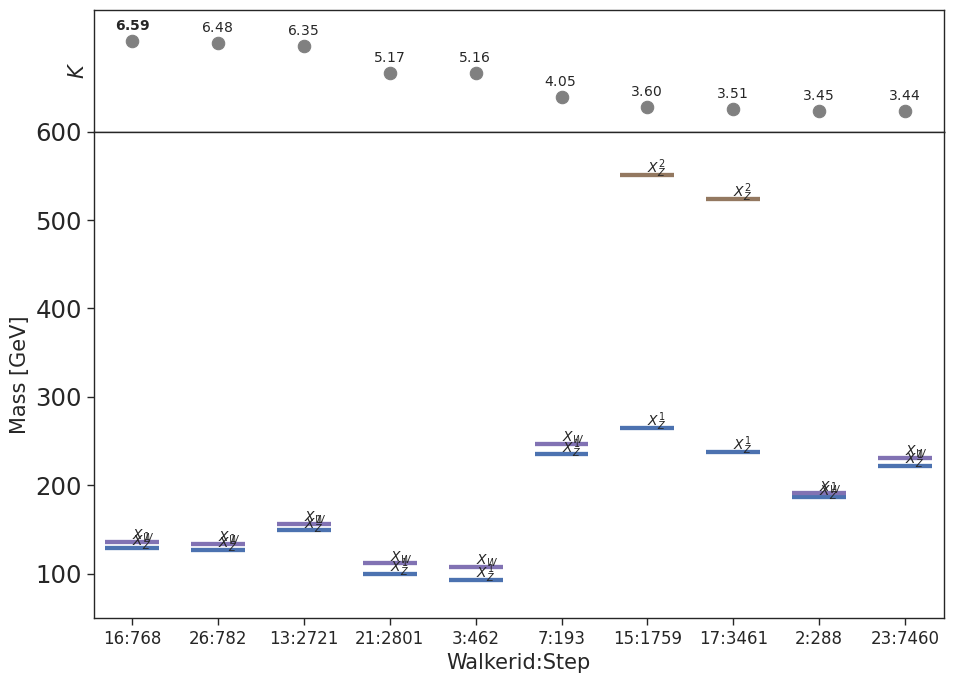

In [23]:
f, axarr = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[1, 4]},figsize=(10,8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0)

nsteps = 10

pids = sorted(list(masses.keys()))

axarr[0].scatter(df['walkerid'],df['K'],s=80,c='gray')
#axarr[0].scatter(df['walkerid'],df['TL'],s=80,c='black')
axarr[0].set_ylabel(r'$K$', fontsize=15)
axarr[0].set_ylim(2.5,8.0)
axarr[0].set_yticks([])
for i,row in df.iterrows():
    index = np.where(walkerid_values == row['walkerid'])[0][0] 
    #print(index)
    if row['K'] == max(df['K']):        
        axarr[0].annotate(r'$\mathbf{%1.2f}$' %row['K'],(index-0.2,row['K']+0.5),
                          fontsize=10)
        #axarr[0].annotate(r'$\mathbf{%1.2f}$' %row['TL'],(index-0.2,row['TL']+0.5),
        #                  fontsize=10)
    else:
        axarr[0].annotate(r'$%1.2f$' %row['K'],(index-0.2,row['K']+0.5),fontsize=10)
        #axarr[0].annotate(r'$%1.2f$' %row['TL'],(index-0.2,row['TL']+0.5),fontsize=10)


for pid in pids:    
    data = df
    sns.scatterplot(x=data['walkerid'],y=data[pid], size=1000,sizes=(1500,1500),marker='_',
                    label=r'$%s$' %(particleLabels[pid]), legend=False,
                    c=[colorDict[pid]],ax=axarr[1])
    index = [np.where(walkerid_values == d['walkerid'])[0][0] for j,d in data.iterrows()]
    for i,m in enumerate(masses[pid]):   
        if m < 0: continue
        #print(particleLabels[pid])
        axarr[1].annotate(r'$%s$' %(particleLabels[pid]),(index[i],m+2),fontsize=10)
axarr[1].set_ylim(50.,600.0)
axarr[1].set_xlabel('Walkerid:Step', fontsize=15)
axarr[1].set_ylabel('Mass [GeV]', fontsize=15)
axarr[1].set_xticks(sorted(df['walkerid'].tolist()), labels =sorted(df['walkerid'].tolist()),  fontsize=12)
#plt.savefig('highScore_massesv1.pdf')
plt.show()

['ATLAS-SUSY-2018-16-hino(em)', 'CMS-EXO-20-004(comb)']
['ATLAS-SUSY-2018-16-hino(em)', 'CMS-EXO-20-004(comb)']
['ATLAS-SUSY-2018-16-hino(em)', 'CMS-EXO-20-004(comb)']
['ATLAS-SUSY-2018-16-hino(em)', 'CMS-EXO-20-004(comb)']
['ATLAS-SUSY-2018-16-hino(em)', 'CMS-EXO-20-004(comb)']
['ATLAS-SUSY-2018-16-hino(em)', 'CMS-EXO-20-004(comb)']
['CMS-SUS-13-012(em)', 'CMS-SUS-20-004(comb)']
['CMS-SUS-13-012(em)', 'CMS-SUS-20-004(comb)']
['ATLAS-SUSY-2018-16-hino(em)', 'CMS-EXO-20-004(comb)']
['ATLAS-SUSY-2018-16-hino(em)', 'CMS-EXO-20-004(comb)']


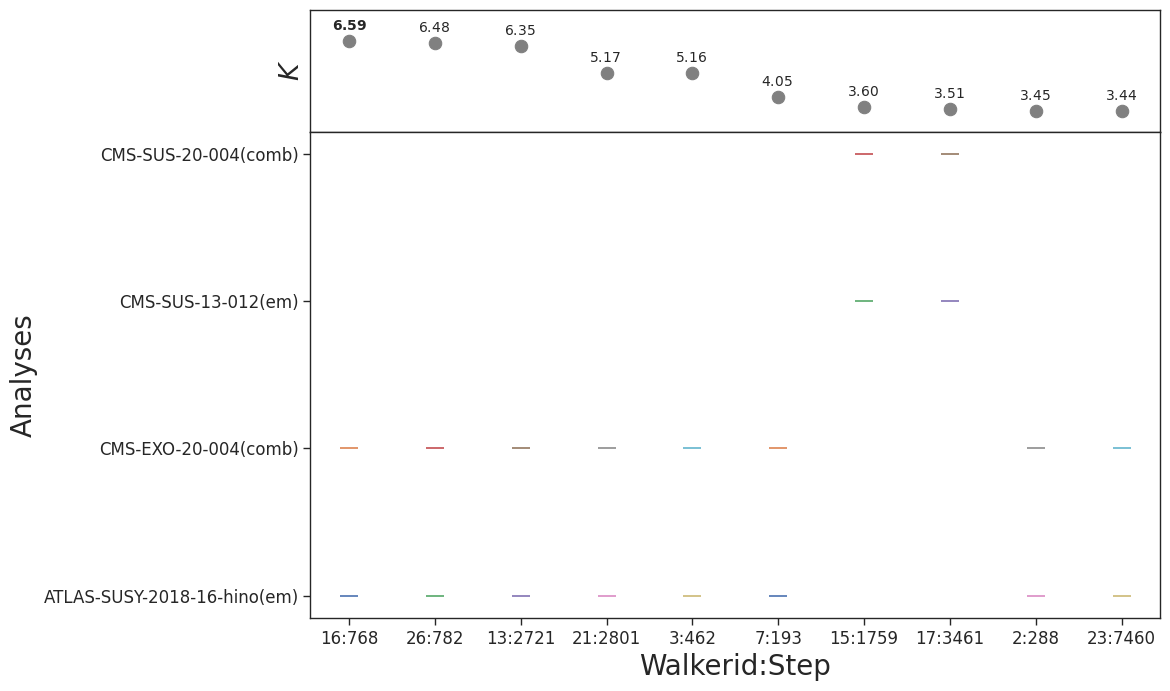

In [24]:
f, axarr = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[1, 4]},figsize=(10,8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0)

nsteps = 10

pids = sorted(list(masses.keys()))

axarr[0].scatter(df['walkerid'],df['K'],s=80,c='gray')
#axarr[0].scatter(df['walkerid'],df['TL'],s=80,c='black')
axarr[0].set_ylabel(r'$K$')
axarr[0].set_ylim(2.5,8.0)
axarr[0].set_yticks([])
for i,row in df.iterrows():
    index = np.where(walkerid_values == row['walkerid'])[0][0] 
    #print(index)
    if row['K'] == max(df['K']):        
        axarr[0].annotate(r'$\mathbf{%1.2f}$' %row['K'],(index-0.2,row['K']+0.5),
                          fontsize=10)
        #axarr[0].annotate(r'$\mathbf{%1.2f}$' %row['TL'],(index-0.2,row['TL']+0.5),
        #                  fontsize=10)
    else:
        axarr[0].annotate(r'$%1.2f$' %row['K'],(index-0.2,row['K']+0.5),fontsize=10)
        #axarr[0].annotate(r'$%1.2f$' %row['TL'],(index-0.2,row['TL']+0.5),fontsize=10)
    bC = sorted(row['bestCombo'].split(','))
    print(bC)
    for j, b in enumerate(bC):
        axarr[1].scatter(row['walkerid'], b, marker='_', s=150)
        index2 = analyses.index(b)
        #axarr[1].annotate(f'{b}',(index-0.2,index2),fontsize=10)
axarr[1].set_xlabel('Walkerid:Step', fontsize=20)
axarr[1].set_ylabel('Analyses', fontsize=20)
axarr[1].set_xticks(sorted(df['walkerid'].tolist()), labels =sorted(df['walkerid'].tolist()),  fontsize=12)
axarr[1].set_yticks(analyses, labels =analyses,  fontsize=12)
'''
for i, ana in enumerate(analyses):
for pid in pids:    
    data = df
    ana = data['bestCombo'].split(',')
    sns.scatterplot(x=data['walkerid'],y=data[pid], size=1000,sizes=(1500,1500),marker='_',
                    label=r'$%s$' %(particleLabels[pid]), legend=False,
                    c=[colorDict[pid]],ax=axarr[1])
    index = [np.where(walkerid_values == d['walkerid'])[0][0] for j,d in data.iterrows()]
    for i,m in enumerate(masses[pid]):   
        if m < 0: continue
        #print(particleLabels[pid])
        axarr[1].annotate(r'$%s$' %(particleLabels[pid]),(index[i],m+10.),fontsize=10)
axarr[1].set_ylim(100.,800.0)
axarr[1].set_xlabel('Walkerid:Step', fontsize=20)
axarr[1].set_ylabel('Mass [GeV]', fontsize=20)
axarr[1].set_xticks(sorted(df['walkerid'].tolist()), labels =sorted(df['walkerid'].tolist()),  fontsize=12)
#plt.savefig('highScore_massesv1.pdf')
'''
plt.show()